# KLASIFIKASI KUALITAS UDARA KOTA-KOTA BESAR DENGAN MODEL DECISION TREE
---

## Anggota Kelompok

| No 	| Nama 	| NIM 	|
|---	|--------------------------	|--------------------	|
| 1 	| Riyan Naffa Nusafara 	| 23/516897/TK/56833 	|
| 2 	| Fadel Aulia Naldi    	| Belum tau             |

## Overview

### Topic Overview

Topik yang kami angkat adalah pengukuran kualitas udara pada kota-kota besar dengan *feature* berupa polutan-polutan udara, antara lain $\text{PM}_{2.5}$, $\text{PM}_{10}$, $\text{O}_{3}$, $\text{NO}_{2}$, $\text{SO}_{2}$, dan $\text{CO}$ serta *target* berupa penilaian kualitas udara yang terdiri atas tiga kelas: *normal*, *elevated*, dan *spiked*. *Normal* merupakan keadaan udara dengan polutan di bawah tingkat bahaya, *elevated* merupakan keadaan udara dengan polutan berada pada tingkat bahaya, dan *spiked* merupakan keadaan udara dengan tingkat polutan yang sangat berbahaya.

### Dataset Overview

Setiap file CSV, yang merupakan data kualitas udara dari kota-kota di dunia, memiliki beberapa kolom:

| location_id | location_name | parameter | value | unit | datetimeUtc | datetimeLocal | timezone | latitude | longitude | country_iso | isMobile | isMonitor | owner_name | provider |

Kolom-kolom seperti `country_iso`, `isMobile`, `isMonitor`, `owner_name`, dan `provider` tidak dibutuhkan dalam analisis sehingga dapat dihilangkan.

Kolom `parameter` berisi polutan-polutan udara atau kondisi udara lainnya. Supaya model klasifikasi dapat berjalan dan dilatih, *dataset* perlu diubah menjadi *wide format*, yakni nilai dari satu parameter atau polutan mengisi satu kolom. Mengubah data menjadi *wide format* dilakukan pada bagian [pemrosesan data](#Data-Preprocessing).

Kolom `parameter` yang akan dianalisis antara lain `pm25`, `pm10`, `o3`, `no2`, `so2`, dan `co`. Nilai `parameter` lainnya dapat dihilangkan.

Import pandas untuk manipulasi data dan os untuk mengambil data dari *directory*.

In [1]:
import pandas as pd
import os

In [ ]:
# Tentukan path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']




In [3]:
# Loop untuk setiap kota dan baca file CSV
for city in cities:
    print(f"\n========== City: {city} ==========\n")
    # Baca file CSV
    # Gunakan try-except untuk menangani kesalahan saat membaca file
    try:
        # Baca file CSV dengan parameter datetimeUtc sebagai datetime
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Tampilkan parameter berbeda pada setiap kota
        print(f"{city} parameter counts:\n", df['parameter'].value_counts(), "\n")
        print("Unique parameter: ", df['parameter'].unique())

        # Tampilkan deskripsi data dan statistik dasar
        print(f"Shape of the dataset: {df.shape}")
        print("Columns in the dataset:", df.columns)
        print("Data types:\n", df.dtypes)
        print("Missing values:\n", df.isnull().sum())
        print("Basic statistics:\n", df.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
    except Exception as e:
        # Jika terjadi kesalahan, tampilkan pesan kesalahan
        print(f"Error processing {city}: {e}")


========== City: Depok ==========

Depok parameter counts:
 parameter
pm1                 1000
pm10                1000
pm25                1000
relativehumidity    1000
temperature         1000
um003               1000
Name: count, dtype: int64 

Unique parameter:  ['pm1' 'pm10' 'pm25' 'relativehumidity' 'temperature' 'um003']
Shape of the dataset: (6000, 15)
Columns in the dataset: Index(['location_id', 'location_name', 'parameter', 'value', 'unit',
       'datetimeUtc', 'datetimeLocal', 'timezone', 'latitude', 'longitude',
       'country_iso', 'isMobile', 'isMonitor', 'owner_name', 'provider'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
parameter                     object
value                        float64
unit                          object
datetimeUtc      datetime64[ns, UTC]
datetimeLocal                 object
timezone                      object
latitude                     float64
longitude                

## Data Preprocessing 1

Menghapus kolom-kolom yang tidak relevan dan melakukan pemisahan kolom bagi `parameter`.

In [4]:
# Path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

# Daftar kolom yang akan dihapus
columns_to_drop = ['provider', 'owner_name', 'isMonitor', 'isMobile', 'country_iso']

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Pivot tabel untuk memecah nilai unik parameter menjadi kolom-kolom yang berbeda
        # dengan index berupa datetime 
        df_wide = df.pivot_table(index=['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude'],
                                 columns='parameter', 
                                 values='value').reset_index()

        print(f"Shape of the dataset: {df_wide.shape}")
        print("Columns in the dataset:", df_wide.columns)
        print("Data types:\n", df_wide.dtypes)
        print("Missing values:\n", df_wide.isnull().sum())
        print("Basic statistics:\n", df_wide.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
        # Set datetime sebagai index
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])
        df_wide.set_index('datetimeUtc', inplace=False)
        
        # Simpan dataframe ke file CSV pada direktori ../data_processed/
        data_processed_dir = "../data_processed/"
        os.makedirs(data_processed_dir, exist_ok=True)
        df_wide.to_csv(os.path.join(data_processed_dir, f"{city}_processed.csv"), index=False)

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']


========== City: Depok ==========

Shape of the dataset: (2309, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003'],
      dtype='object', name='parameter')
Data types:
 parameter
location_id                       int64
location_name                    object
datetimeUtc         datetime64[ns, UTC]
latitude                        float64
longitude                       float64
pm1                             float64
pm10                            float64
pm25                            float64
relativehumidity                float64
temperature                     float64
um003                           float64
dtype: object
Missing values:
 parameter
location_id            0
location_name          0
datet

<Axes: xlabel='parameter', ylabel='parameter'>

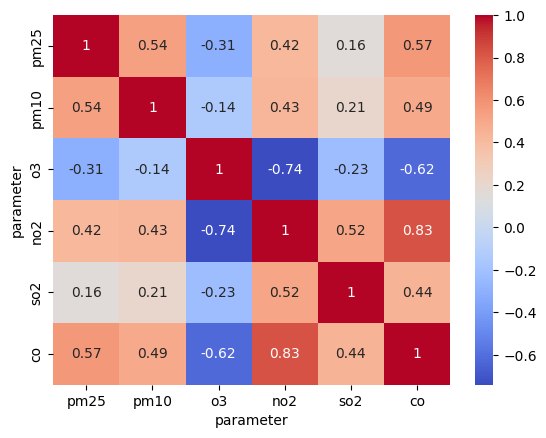

In [6]:
# Cek korelasi antar polutan
import seaborn as sns
corr = df_wide[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


## Visualisasi Data

Tampilkan *scatterplot* untuk setiap kota.

In [9]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

Files in ../data_processed/: ['Depok_processed.csv', 'Hanoi_processed.csv', 'London_processed.csv', 'Madrid_processed.csv', 'Napoli_processed.csv', 'New Delhi_processed.csv', 'New Jersey_processed.csv', 'Paris_processed.csv', 'Riverside_processed.csv']


========== City: Depok ==========



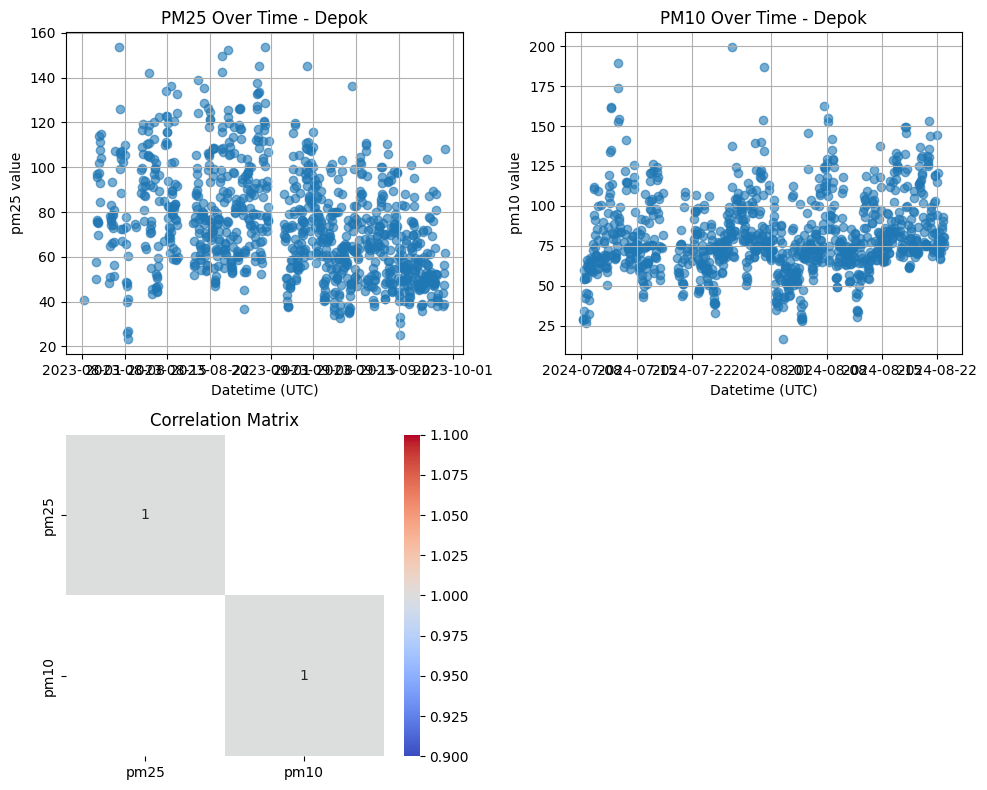

========== City: Hanoi ==========



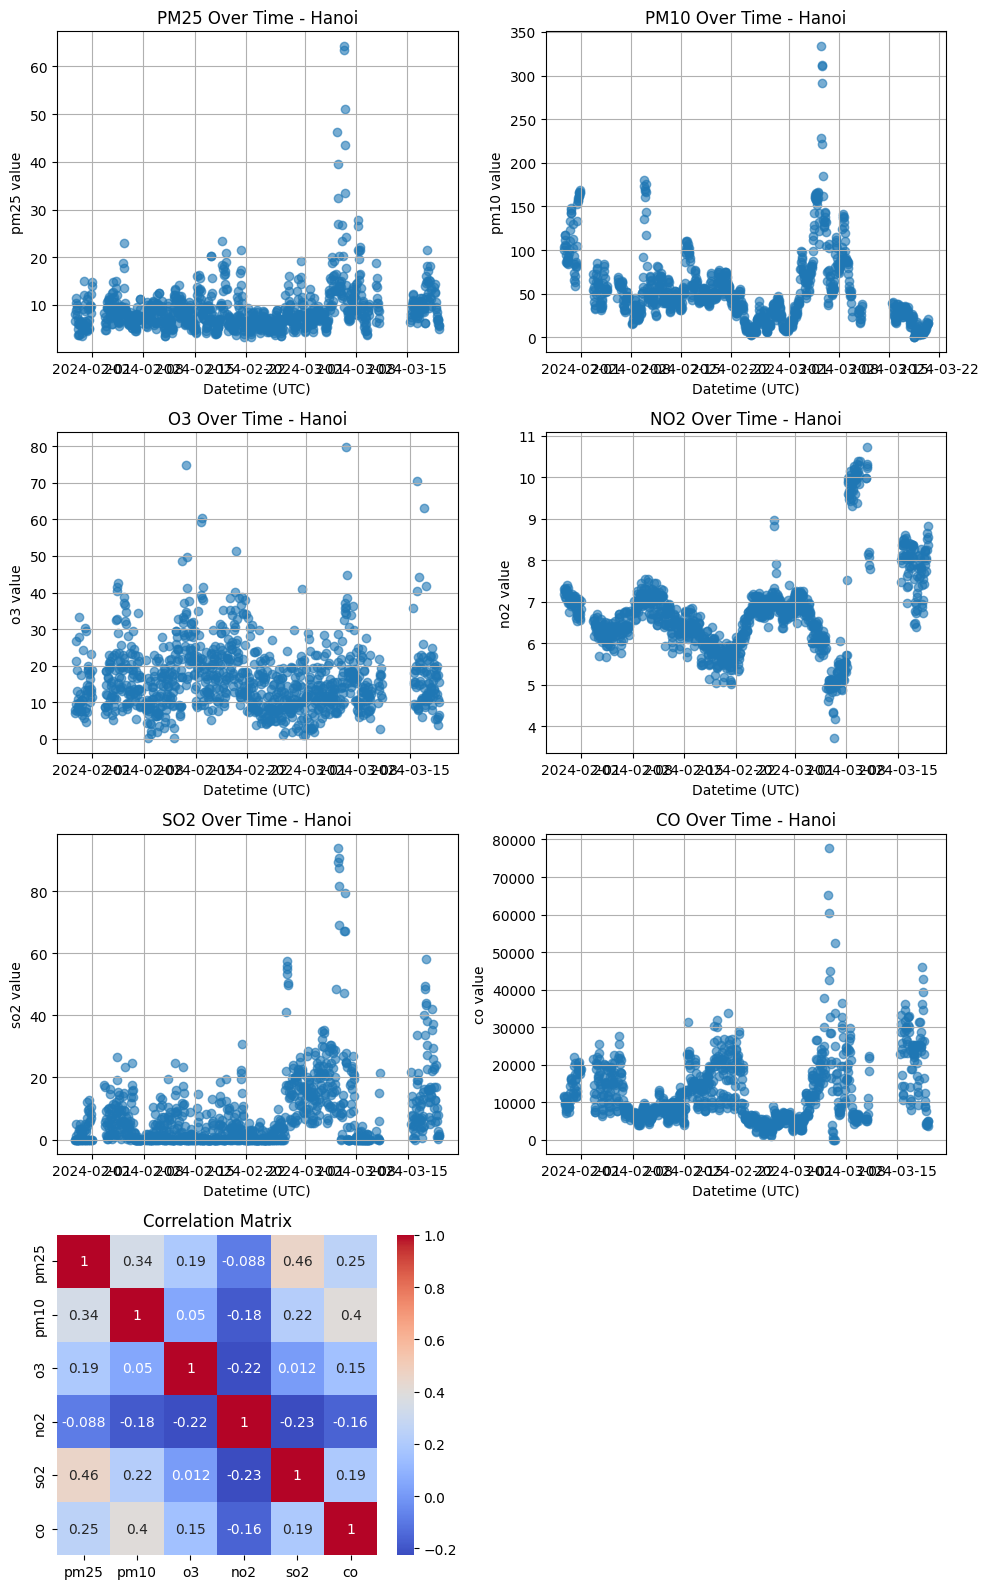

========== City: London ==========



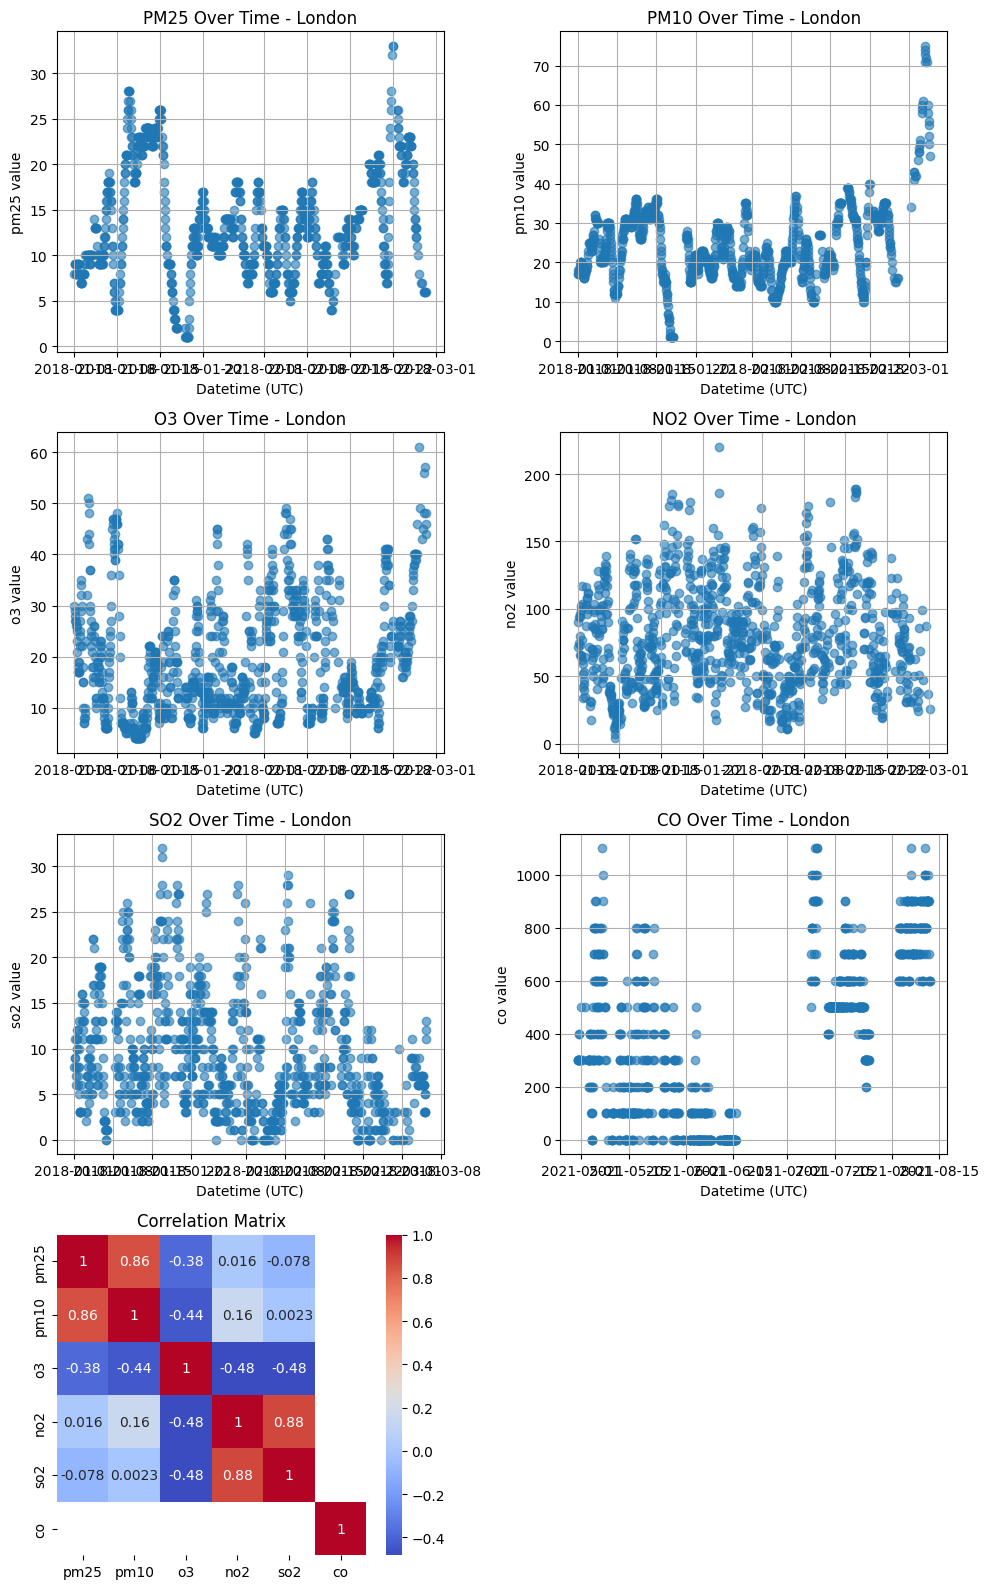

========== City: Madrid ==========



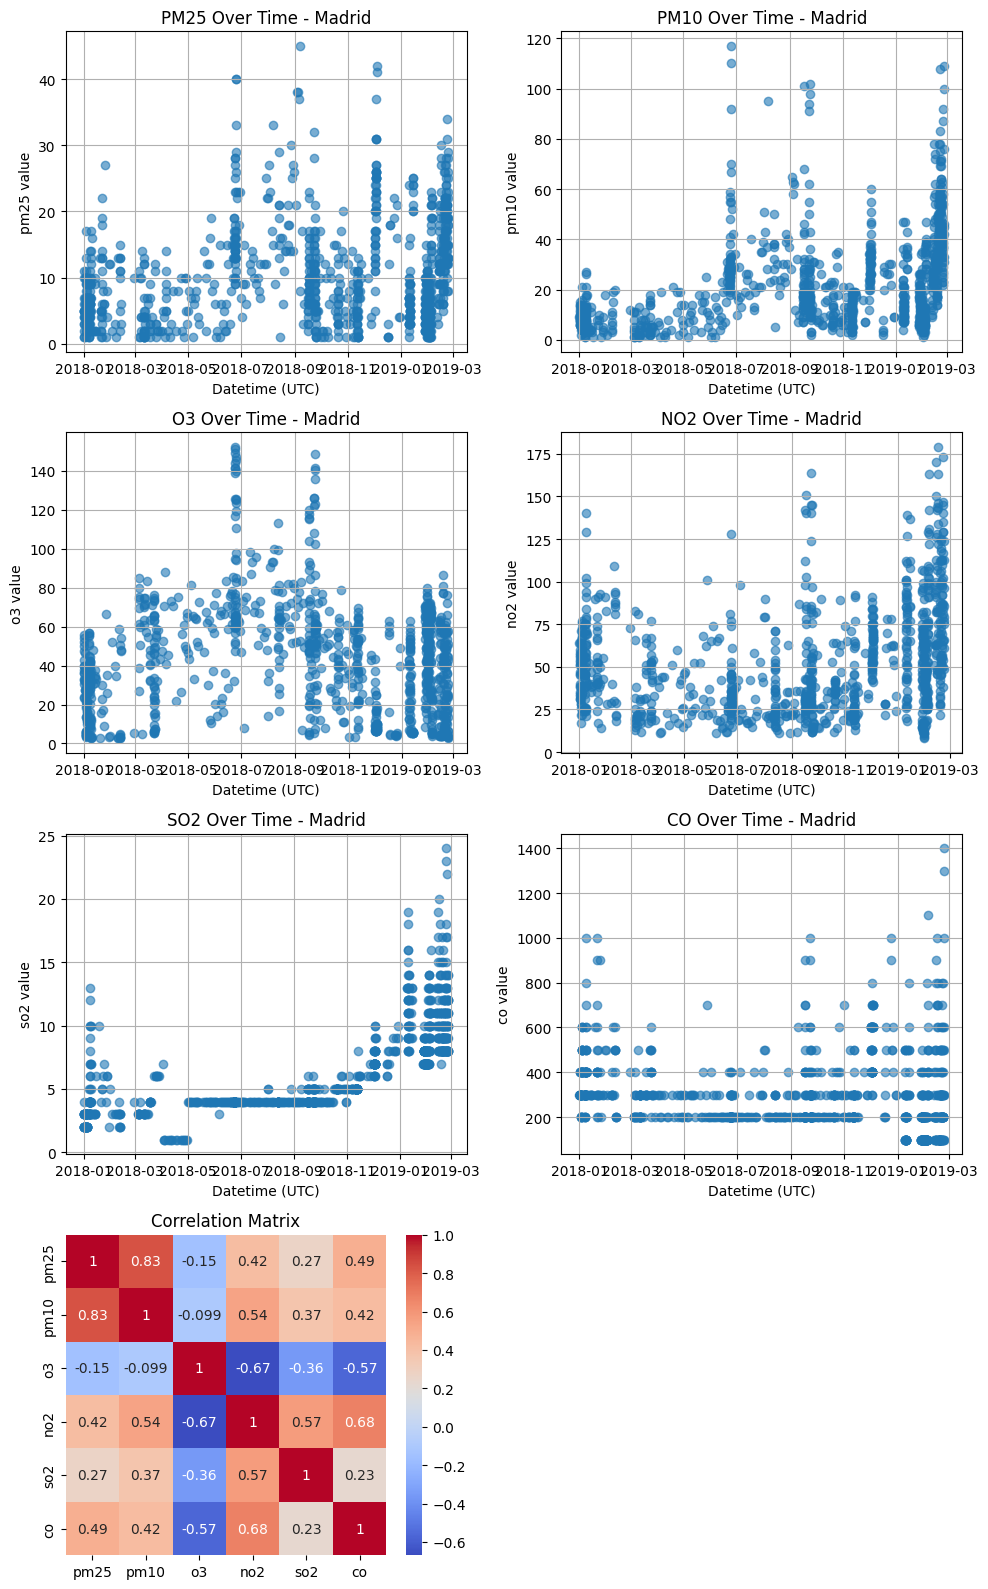

========== City: Napoli ==========



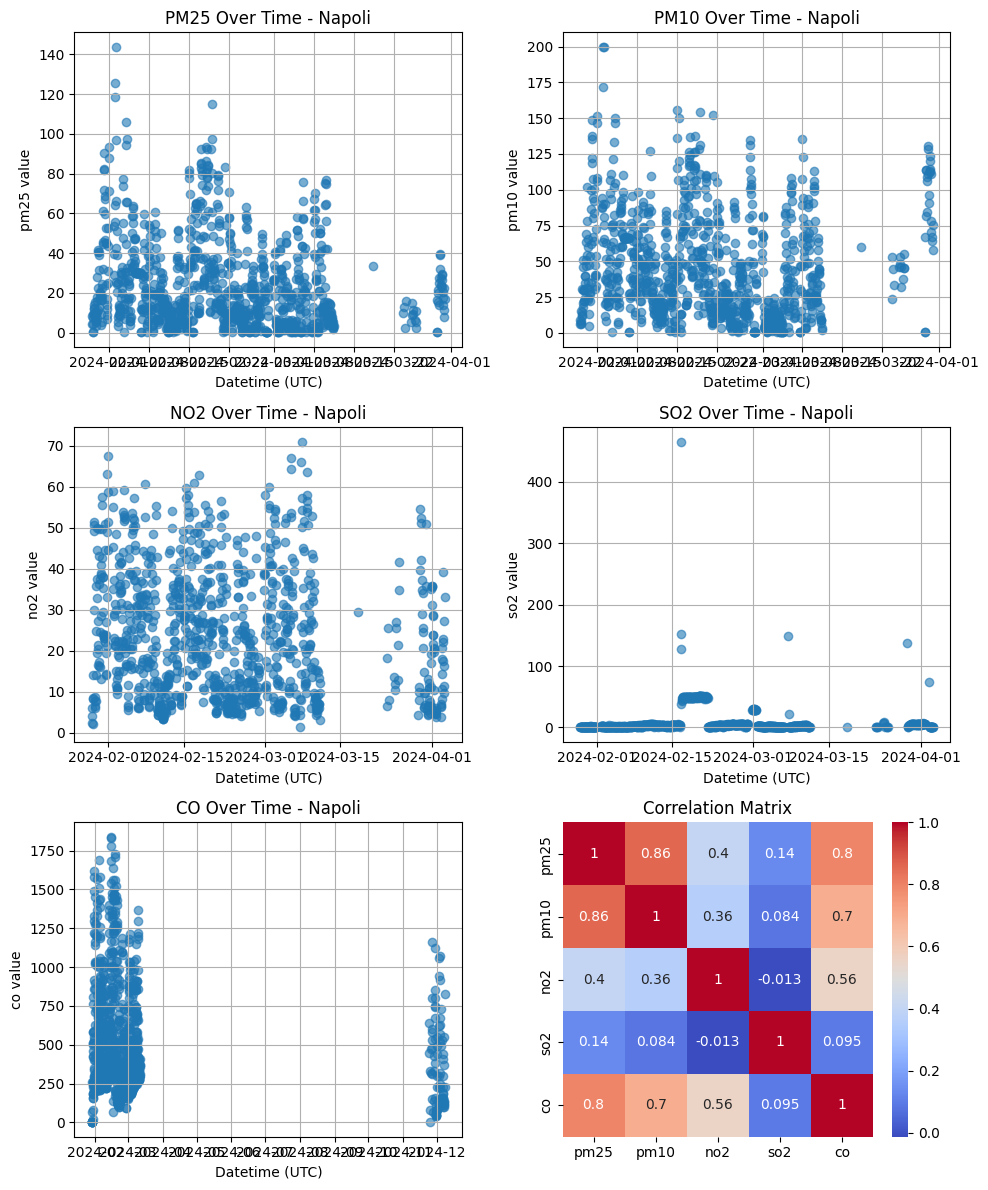

========== City: New Delhi ==========



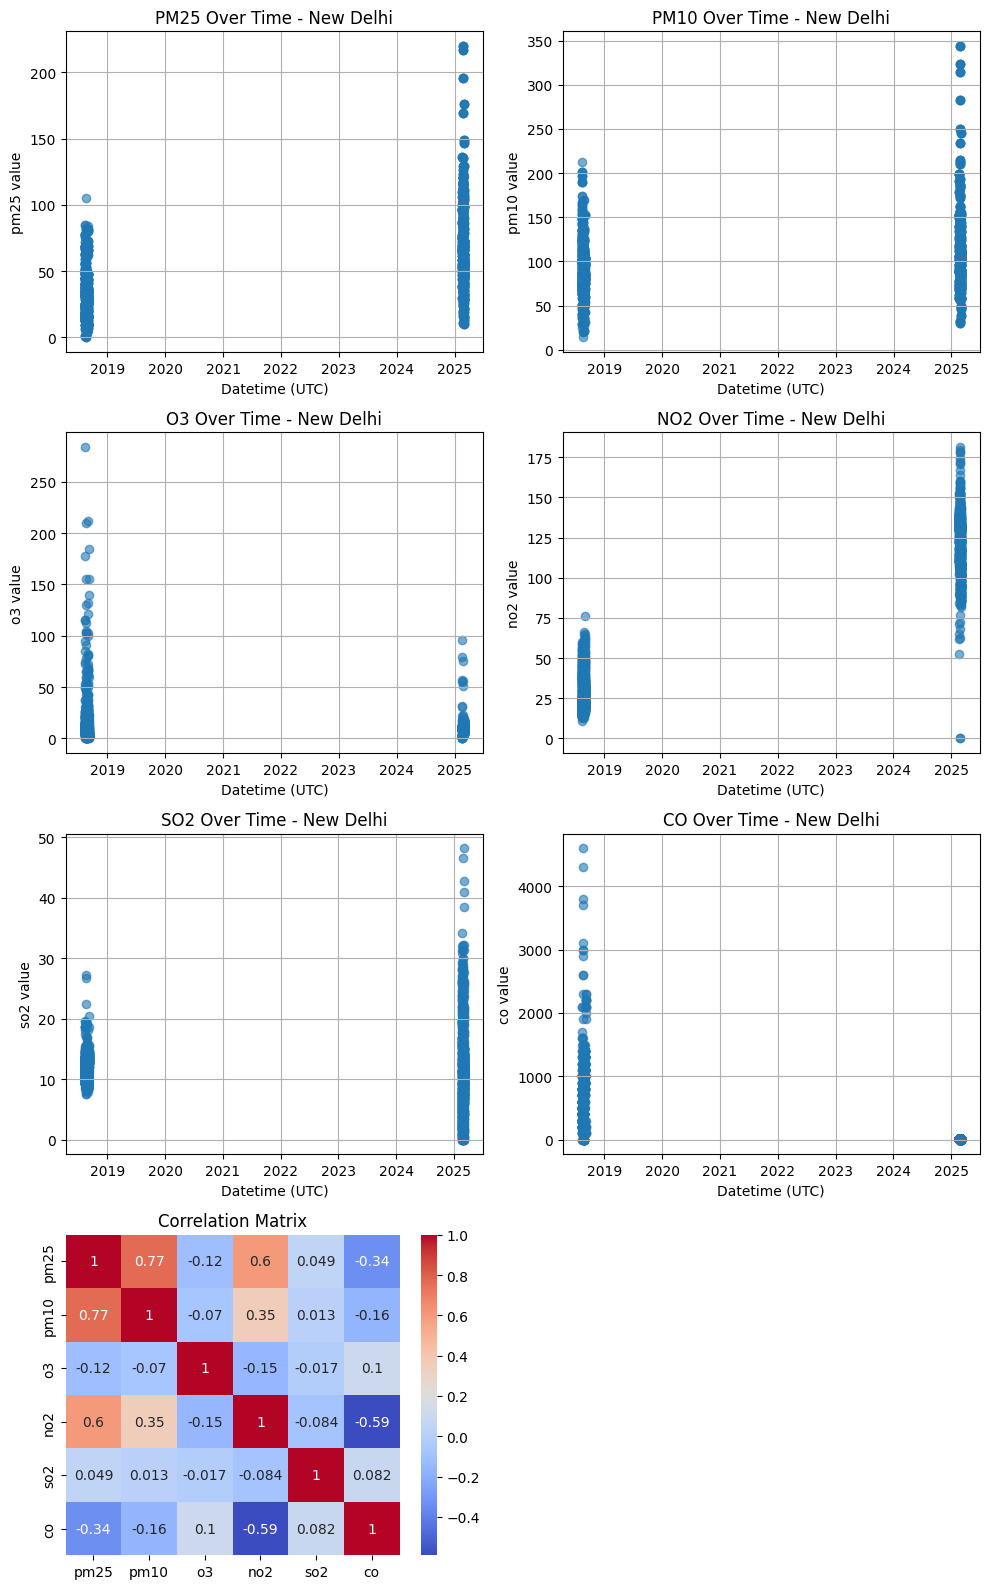

========== City: New Jersey ==========



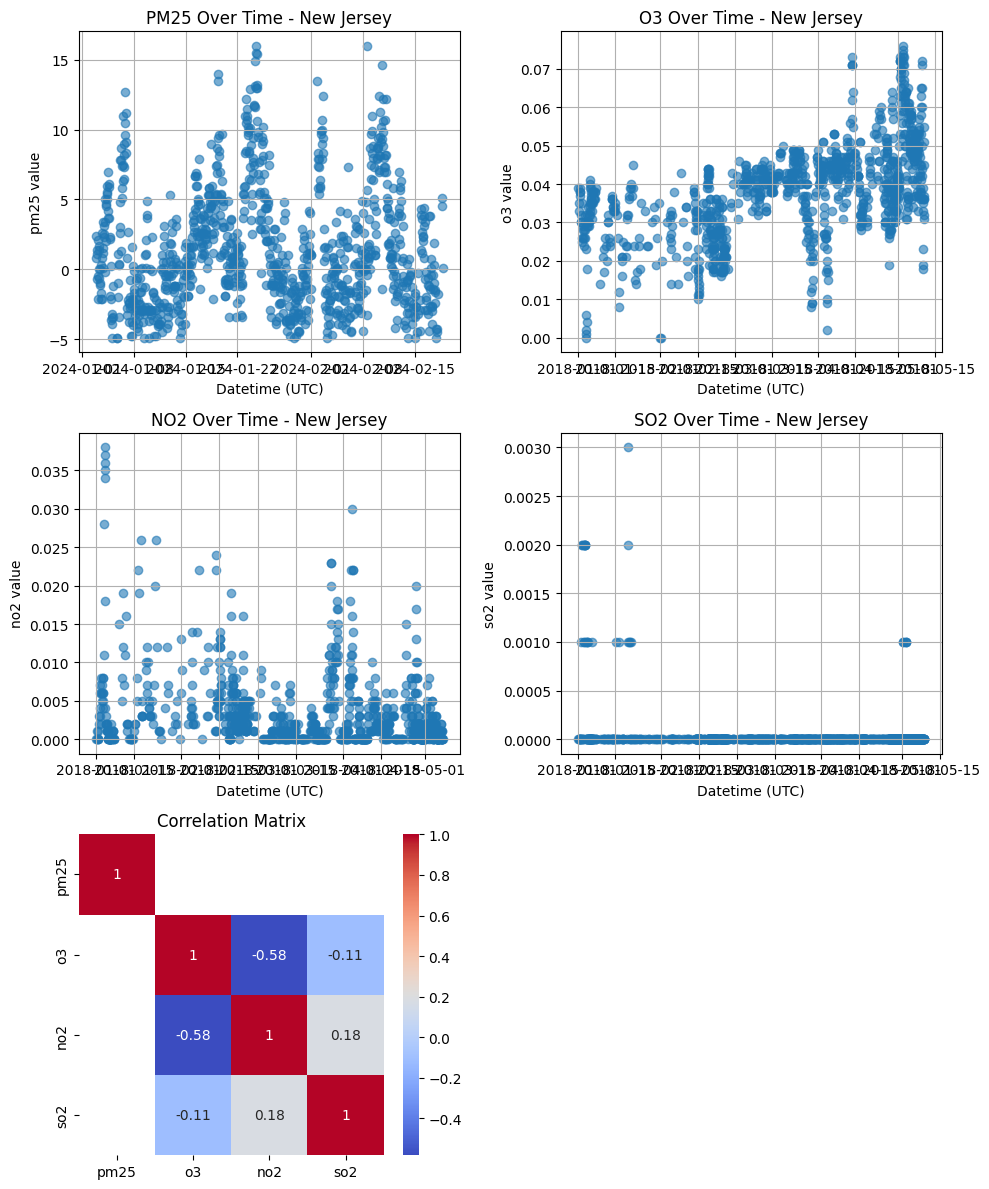

========== City: Paris ==========



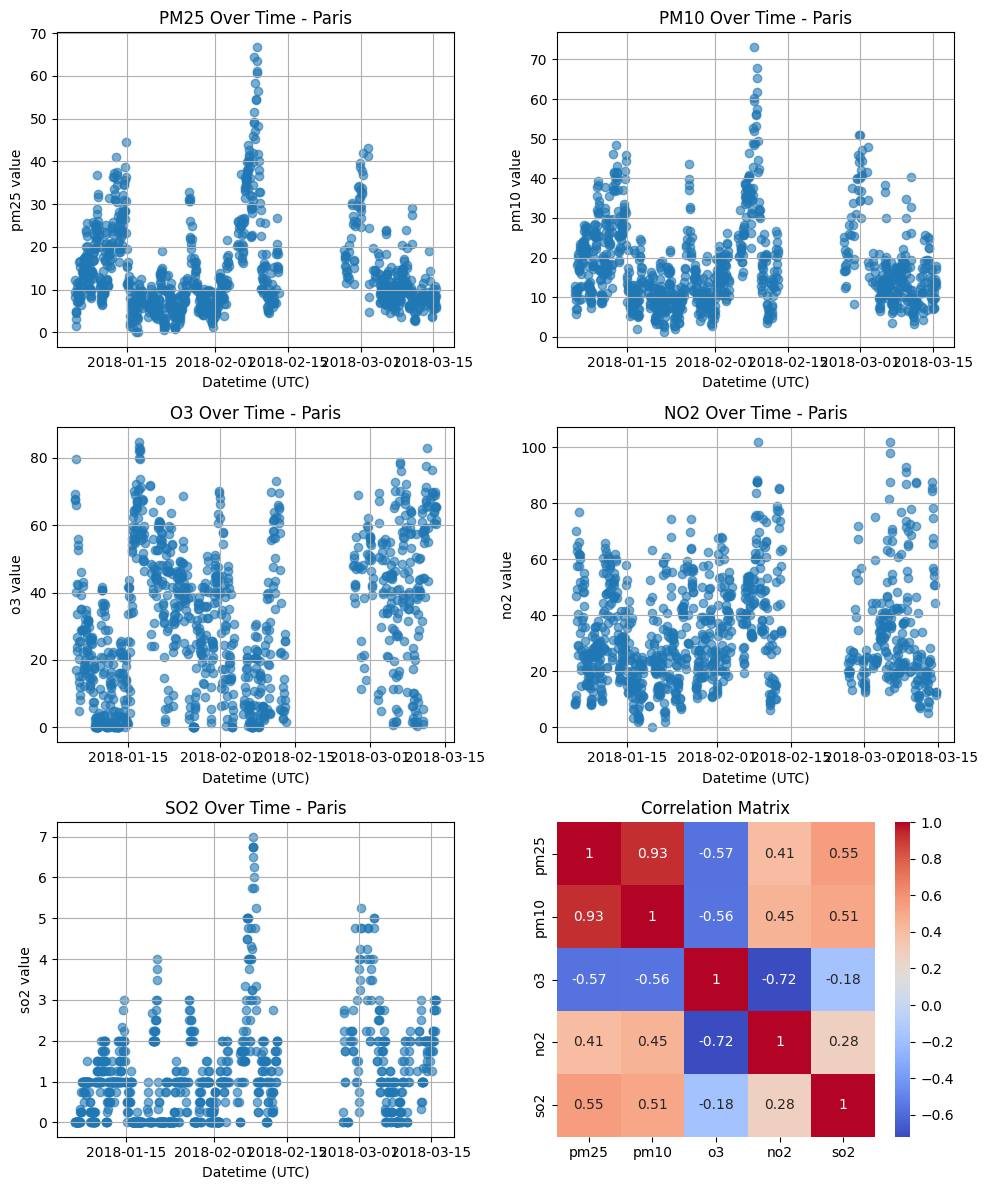

========== City: Riverside ==========



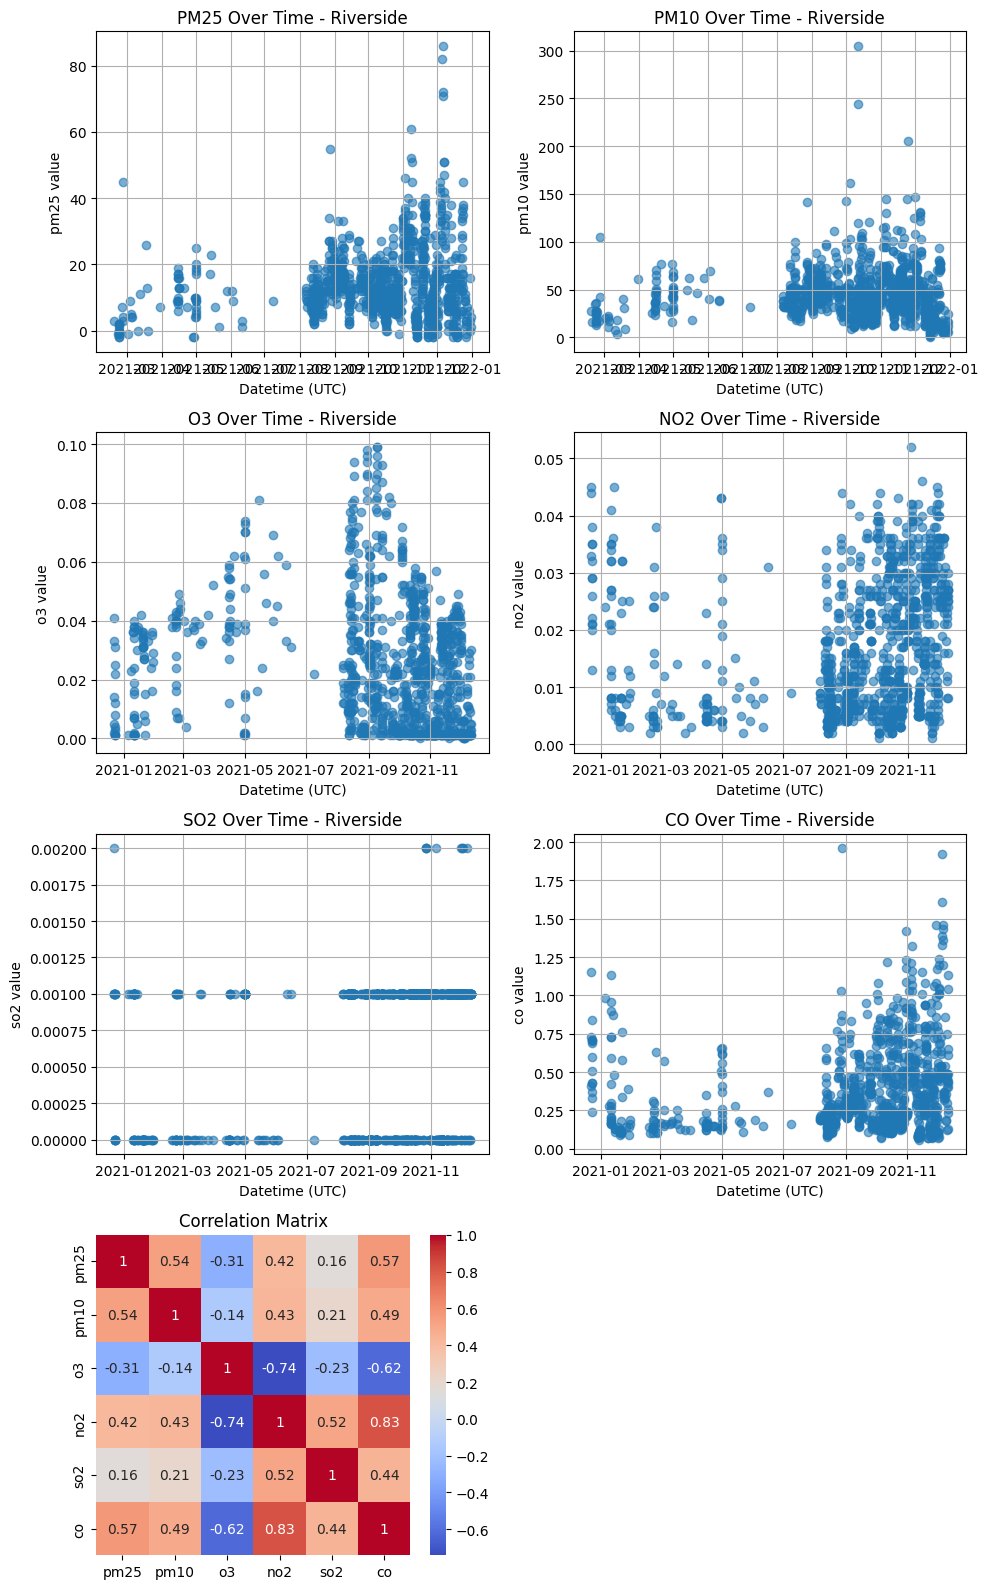

In [17]:
# Required for inline plotting in Jupyter
%matplotlib inline

# Define the path to the data directory
data_dir = "../data_processed/"

# List all files in the data directory
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

cities = [file[:-14] for file in files if file.endswith('.csv')]

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df_wide = pd.read_csv(os.path.join(data_dir, f"{city}_processed.csv"), parse_dates=['datetimeUtc'])
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])

        # Tentukan polutan-polutan yang ada pada data suatu kota
        pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
        available_pollutants = [col for col in pollutant_cols if col in df_wide.columns]

        all_cols = available_pollutants
        n = len(all_cols)
        add_corr_matrix = True

        if n == 0:
            print(f"No pollutant data available for {city}")
        else:
            total_plots = n + (1 if add_corr_matrix else 0)
            cols = 2
            rows = math.ceil(total_plots / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), sharex=False)
            axes = axes.flatten()

            # Plot setiap polutan pada subplot yang berbeda
            for i, col in enumerate(all_cols):
                axes[i].scatter(df_wide['datetimeUtc'], df_wide[col], color='tab:blue', alpha=0.6)
                axes[i].set_title(f"{col.upper()} Over Time - {city}")
                axes[i].set_xlabel("Datetime (UTC)")
                axes[i].set_ylabel(f"{col} value")
                axes[i].grid(True)

            # Plot correlation matrix pada subplot terakhir 
            if add_corr_matrix:
                corr = df_wide[available_pollutants].corr()
                sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[n])
                axes[n].set_title("Correlation Matrix")

            # Sembunyikan subplot yang tidak digunakan
            for j in range(n + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

## Data Preprocessing 2

Supaya data dapat digunakan untuk training, kolom-kolom data harus berupa feature dan target. Langkah selanjutnya pada preprocessing data adalah untuk menghapus kolom-kolom non-feature dan melihat bentuknya.

In [18]:
import pandas as pd
import os

# Define the path to the data directory
data_dir = os.path.abspath("../data_processed/")

# List all CSV files in the data directory
files = [file for file in os.listdir(data_dir) if file.endswith('.csv')]
print(f"CSV files in {data_dir}: {files}\n")

# Columns to drop
columns_to_drop = ['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude', 'relativehumidity', 'temperature']
pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

# Initialize an empty DataFrame for merging with columns set to pollutant_cols
df_merged = pd.DataFrame(columns=pollutant_cols)

# Process each file
for file in files:
    try:
        file_path = os.path.join(data_dir, file)
        df_wide = pd.read_csv(file_path, parse_dates=['datetimeUtc'])
        
        # Drop specified columns
        df_wide.drop(columns=columns_to_drop, inplace=True, errors='ignore')
        
        # Align columns and concatenate to the merged DataFrame, filling missing values with NaN
        df_wide = df_wide.reindex(columns=pollutant_cols, fill_value=pd.NA)
        df_merged = pd.concat([df_merged, df_wide], ignore_index=True)
        
    except Exception as e:
        print(f"Could not process file {file}: {e}")

# Optional: Save the merged DataFrame to a CSV file
data_merged_dir = os.path.abspath("../data_merged/")
output_path = os.path.join(data_merged_dir, "merged_data.csv")
df_merged.to_csv(output_path, index=False)
print(f"Merged data saved to {output_path}")

CSV files in d:\Kulyah\smt-4\ai\ai-project-25\data_processed: ['Depok_processed.csv', 'Hanoi_processed.csv', 'London_processed.csv', 'Madrid_processed.csv', 'Napoli_processed.csv', 'New Delhi_processed.csv', 'New Jersey_processed.csv', 'Paris_processed.csv', 'Riverside_processed.csv']

Merged data saved to d:\Kulyah\smt-4\ai\ai-project-25\data_merged\merged_data.csv


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_44828\1437864503.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_merged = pd.concat([df_merged, df_wide], ignore_index=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_44828\1437864503.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_merged = pd.concat([df_merged, df_wide], ignore_index=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_44828\1437864503.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA

In [20]:
print(df_merged.describe())
print("Null values:")
print(df_merged.isnull().sum())

               pm25         pm10           o3          no2          so2  \
count  10000.000000  9000.000000  8000.000000  9000.000000  9000.000000   
mean      26.090650    54.318862    16.806638    38.239365     6.280690   
std       29.535239    42.600329    21.065352    42.419426    10.220778   
min       -4.900000     0.000000     0.000000     0.000000     0.000000   
25%        7.000000    20.000000     0.072000     5.867500     0.001000   
50%       13.410000    43.000000     9.600000    23.100000     3.170000   
75%       35.647500    79.235923    22.092500    56.000000    10.000000   
max      220.000000   344.000000   283.900000   220.000000   465.520000   

                 co  
count   7000.000000  
mean    2056.252530  
std     5369.935705  
min        0.000000  
25%        1.447500  
50%      300.000000  
75%      700.000000  
max    77684.800000  
Null values:
pm25     8636
pm10     9636
o3      10636
no2      9636
so2      9636
co      11636
dtype: int64


Karena masih terdapat nilai-nilai NaN atau empty, baris-baris tersebut harus diisi dengan imputasi data.

## Pengembangan Model

## Model Training dan Validasi

## Model Testing

## Kesimpulan